# 02 — EMRI Trajectory Integration

This notebook covers `fewtrax.trajectory.inspiral` — the adiabatic EMRI inspiral ODE.

**Topics:**
- The adiabatic inspiral ODE and the $\mu/M$ mass-ratio scaling
- Converting radiation-reaction forces $(\dot{E}, \dot{L})$ to $(\dot{p}, \dot{e})$ via the geodesic Jacobian
- diffrax `Tsit5` adaptive solver with separatrix event termination
- JIT compilation and `@eqx.filter_jit`
- Visualising $p(t)$, $e(t)$, and the orbital phases $\Phi_\phi(t)$

---

## Background: The Adiabatic Approximation

In the **adiabatic approximation** the mass ratio $\eta = \mu/M \ll 1$ allows a separation of timescales:
- *Fast*: orbital motion (Boyer–Lindquist period $T_{\rm orb} \sim M$)
- *Slow*: radiation-reaction (inspiral timescale $T_{\rm insp} \sim M/\eta \sim 10^5\,{\rm yr}$ for a typical EMRI)

On the slow timescale, the orbital parameters $(p, e)$ evolve according to

$$
\frac{dp}{dt} = \dot{p}(a, p, e), \qquad \frac{de}{dt} = \dot{e}(a, p, e)
$$

driven by the orbit-averaged energy and angular-momentum fluxes $\langle\dot{E}\rangle$, $\langle\dot{L}\rangle$.  The orbital phases advance at the instantaneous geodesic frequencies:

$$
\dot{\Phi}_\phi = \Omega_\phi(a, p, e), \quad \dot{\Phi}_\theta = \Omega_\theta, \quad \dot{\Phi}_r = \Omega_r.
$$

Time here is Boyer–Lindquist coordinate time in units of $M$.

### Converting $(\dot{E}, \dot{L})$ to $(\dot{p}, \dot{e})$

The FEW flux tables provide $(\dot{E}, \dot{L})$ normalised to the Peters (1964) PN expressions.  To get $(\dot{p}, \dot{e})$ we invert the $2 \times 2$ Jacobian

$$
J = \begin{pmatrix} \partial E/\partial p & \partial E/\partial e \\ \partial L/\partial p & \partial L/\partial e \end{pmatrix}, \qquad
\begin{pmatrix} \dot{p} \\ \dot{e} \end{pmatrix} = J^{-1} \begin{pmatrix} \dot{E} \\ \dot{L} \end{pmatrix}.
$$

$J$ is computed automatically via `jax.jacfwd`.

> **Note:** At $e = 0$ both $\partial E/\partial e = \partial L/\partial e = 0$ (circular orbit symmetry), making $J$ singular.  fewtrax handles this by using the circular-orbit fallback $\dot{p} = \dot{E}/(\partial E/\partial p)$, $\dot{e} = 0$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")

from fewtrax.data import load_flux_data
from fewtrax.trajectory import run_inspiral, EMRIInspiral
from fewtrax.trajectory.inspiral import SEPARATRIX_BUFFER

print("Loading flux data…")
flux_data = load_flux_data(DATA_DIR)
print("Done.")

FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data
Loading flux data…
Done.


## 2.1  Running a Single Inspiral

`run_inspiral` is a convenience wrapper around `EMRIInspiral`.  It returns six JAX arrays:

| Array | Units | Description |
|---|---|---|
| `t` | seconds | Observer time |
| `p` | $M$ | Semi-latus rectum |
| `e` | — | Eccentricity |
| `Phi_phi` | rad | Azimuthal phase |
| `Phi_theta` | rad | Polar phase |
| `Phi_r` | rad | Radial phase |

In [11]:
t, p, e, Phi_phi, Phi_theta, Phi_r = run_inspiral(
    a       = 0.95,     # BH spin
    p0      = 6.0,    # initial semi-latus rectum [M]
    e0      = 0.4,     # initial eccentricity
    T       = 1.0,     # observation time [years]
    flux_data = flux_data,
    M       = 1e6,     # primary mass [M_sun]
    mu      = 10.0,    # secondary mass [M_sun]
    # dense_steps = 200, # number of saved trajectory points
)

valid = ~np.isinf(np.asarray(p))
print(f"Trajectory points computed: {valid.sum()} / {len(p)}")
print(f"p: {float(p[0]):.4f} -> {float(p[valid][-1]):.4f}  [M]")
print(f"e: {float(e[0]):.4f} -> {float(e[valid][-1]):.4f}")
print(f"Total azimuthal phase: {float(Phi_phi[valid][-1])/(2*np.pi):.1f} radians")

Trajectory points computed: 58 / 101
p: 6.0000 -> 2.0109  [M]
e: 0.4000 -> 0.0987
Total azimuthal phase: 51147.0 radians


In [12]:
valid.sum()

np.int64(58)

In [13]:
p[valid]

Array([6.        , 5.97281522, 5.94524515, 5.91727811, 5.88890184,
       5.86010347, 5.83086947, 5.80118561, 5.77103692, 5.74040761,
       5.70928102, 5.67763955, 5.6454646 , 5.61273647, 5.5794343 ,
       5.54553593, 5.51101781, 5.4758549 , 5.44002048, 5.40348605,
       5.36622117, 5.32819319, 5.2893671 , 5.24970527, 5.20916721,
       5.16770917, 5.12528387, 5.08184003, 5.03732193, 4.99166889,
       4.94481454, 4.89668617, 4.84720385, 4.79627936, 4.74381504,
       4.68970225, 4.63381974, 4.57603144, 4.51618386, 4.45410297,
       4.38959016, 4.3224172 , 4.25231989, 4.17898965, 4.10206266,
       4.02110525, 3.93559386, 3.84488716, 3.74818576, 3.64447246,
       3.53241958, 3.41023772, 3.27541257, 3.12420328, 2.95055646,
       2.7432272 , 2.47457985, 2.01091325], dtype=float64)

In [14]:
print(f't = {t[valid]}')
print(f'p = {p[valid]}')
print(f'e = {e[valid]}')

t = [       0.           318769.18953076   637538.37906153   956307.56859229
  1275076.75812305  1593845.94765382  1912615.13718458  2231384.32671535
  2550153.51624611  2868922.70577687  3187691.89530764  3506461.0848384
  3825230.27436916  4143999.46389993  4462768.65343069  4781537.84296145
  5100307.03249222  5419076.22202298  5737845.41155375  6056614.60108451
  6375383.79061527  6694152.98014604  7012922.1696768   7331691.35920756
  7650460.54873833  7969229.73826909  8287998.92779985  8606768.11733062
  8925537.30686138  9244306.49639215  9563075.68592291  9881844.87545367
 10200614.06498444 10519383.2545152  10838152.44404596 11156921.63357673
 11475690.82310749 11794460.01263825 12113229.20216902 12431998.39169978
 12750767.58123055 13069536.77076131 13388305.96029207 13707075.14982283
 14025844.3393536  14344613.52888436 14663382.71841513 14982151.90794589
 15300921.09747665 15619690.28700742 15938459.47653818 16257228.66606895
 16575997.85559971 16894767.04513047 17213536.23

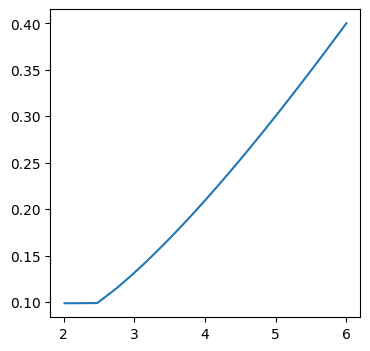

In [15]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

ax.plot(p[valid], e[valid], label='Orbital trajectory')

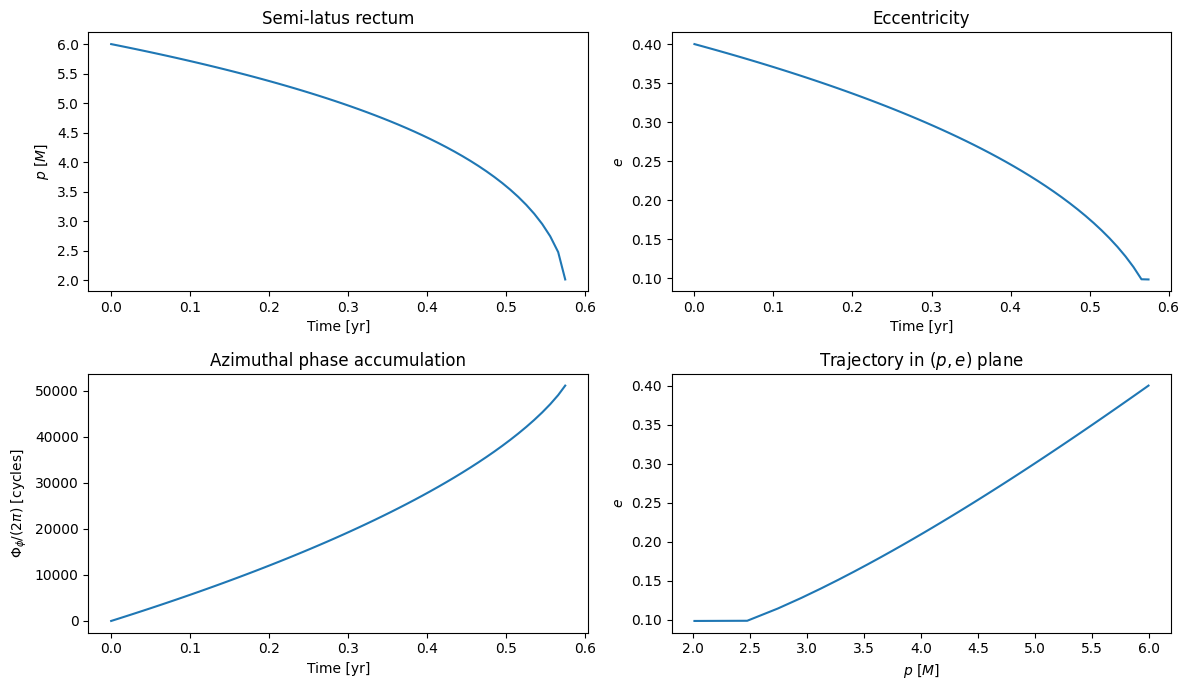

In [16]:
t_yr = np.asarray(t)[valid] / (365.25 * 24 * 3600)
p_np = np.asarray(p)[valid]
e_np = np.asarray(e)[valid]
Pphi = np.asarray(Phi_phi)[valid] / (2 * np.pi)  # in cycles
Pr   = np.asarray(Phi_r)[valid]   / (2 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0,0].plot(t_yr, p_np)
axes[0,0].set_xlabel("Time [yr]")
axes[0,0].set_ylabel("$p$ [$M$]")
axes[0,0].set_title("Semi-latus rectum")

axes[0,1].plot(t_yr, e_np)
axes[0,1].set_xlabel("Time [yr]")
axes[0,1].set_ylabel("$e$")
axes[0,1].set_title("Eccentricity")

axes[1,0].plot(t_yr, Pphi)
axes[1,0].set_xlabel("Time [yr]")
axes[1,0].set_ylabel("$\\Phi_\\phi / (2\\pi)$ [cycles]")
axes[1,0].set_title("Azimuthal phase accumulation")

axes[1,1].plot(p_np, e_np)
axes[1,1].set_xlabel("$p$ [$M$]")
axes[1,1].set_ylabel("$e$")
axes[1,1].set_title("Trajectory in $(p, e)$ plane")

# plt.suptitle(f"EMRI inspiral: $a=0.7$, $M=10^6\\,M_\\odot$, $\\mu=10\\,M_\\odot$, $T=1\\,{\\rm yr}$")
plt.tight_layout()
plt.show()

## 2.2  The μ/M Mass-Ratio Scaling

The FEW flux tables are normalised to $\mu = M = 1$ (geometric units).  To convert to physical units:

$$
\dot{p}_{\rm phys} = \frac{\mu}{M} \cdot \dot{p}_{\rm table}, \qquad \dot{e}_{\rm phys} = \frac{\mu}{M} \cdot \dot{e}_{\rm table}
$$

For a typical EMRI: $\mu/M = 10/10^6 = 10^{-5}$, so the inspiral rate is 100,000 times slower than the flux-table value.  The orbital phases $\Phi_\phi$, $\Phi_r$ are **not** scaled by $\mu/M$ — they accumulate at the geodesic frequencies regardless of mass ratio.

Let's check how the inspiral depth scales with the mass ratio:

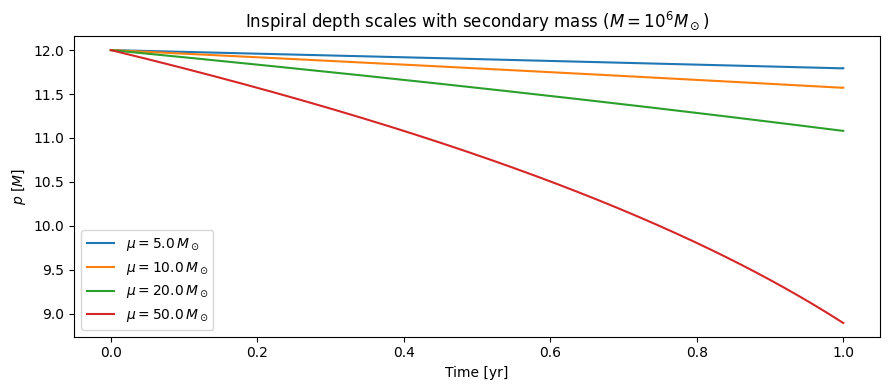

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))

for mu_val, color in zip([5.0, 10.0, 20.0, 50.0], ["C0", "C1", "C2", "C3"]):
    t_, p_, *_ = run_inspiral(
        a=0.7, p0=12.0, e0=0.4, T=1.0,
        flux_data=flux_data, M=1e6, mu=mu_val, dense_steps=150,
    )
    valid_ = ~np.isnan(np.asarray(p_))
    t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)
    ax.plot(t_yr_, np.asarray(p_)[valid_], color=color, label=f"$\\mu = {mu_val}\\,M_\\odot$")

ax.set_xlabel("Time [yr]")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("Inspiral depth scales with secondary mass ($M = 10^6 M_\\odot$)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.3  Circular Orbit (e = 0)

Circular orbits are a special case.  For $e = 0$ the Jacobian $J$ is singular (both $\partial E/\partial e$ and $\partial L/\partial e$ vanish at $e = 0$ by symmetry). The ocde detects this and uses a fallback formula for circular orbits:

$$
\dot{p} = \frac{\dot{E}}{\partial E/\partial p}, \qquad \dot{e} = 0
$$

Circular orbits evolve along the circular-orbit sequence and stay circular throughout.

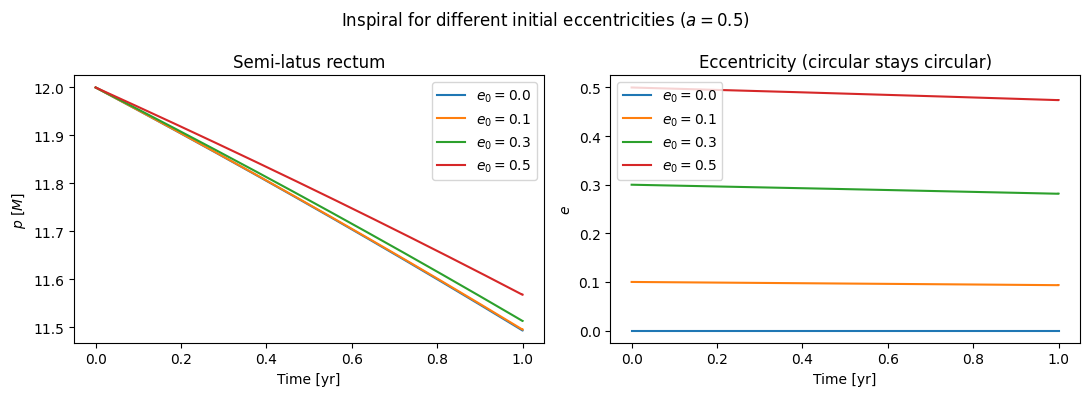

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for e0_val, color in zip([0.0, 0.1, 0.3, 0.5], ["C0", "C1", "C2", "C3"]):
    t_, p_, e_, *_ = run_inspiral(
        a=0.5, p0=12.0, e0=e0_val, T=1.0,
        flux_data=flux_data, M=1e6, mu=10.0, dense_steps=150,
    )
    valid_ = ~np.isnan(np.asarray(p_))
    t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)
    axes[0].plot(t_yr_, np.asarray(p_)[valid_], color=color, label=f"$e_0={e0_val}$")
    axes[1].plot(t_yr_, np.asarray(e_)[valid_], color=color, label=f"$e_0={e0_val}$")

axes[0].set_xlabel("Time [yr]")
axes[0].set_ylabel("$p$ [$M$]")
axes[0].set_title("Semi-latus rectum")
axes[0].legend()

axes[1].set_xlabel("Time [yr]")
axes[1].set_ylabel("$e$")
axes[1].set_title("Eccentricity (circular stays circular)")
axes[1].legend()

plt.suptitle("Inspiral for different initial eccentricities ($a = 0.5$)")
plt.tight_layout()
plt.show()

## 2.4  Separatrix Termination

The ODE is stopped when $p < p_{\rm sep}(a, e) + \delta p_{\rm buffer}$.  This is implemented as a `diffrax.Event` with a boolean condition.  After termination, the remaining `dense_steps` entries are filled with `Inf`.  Always mask with `~np.isinf(p)` before analysis.

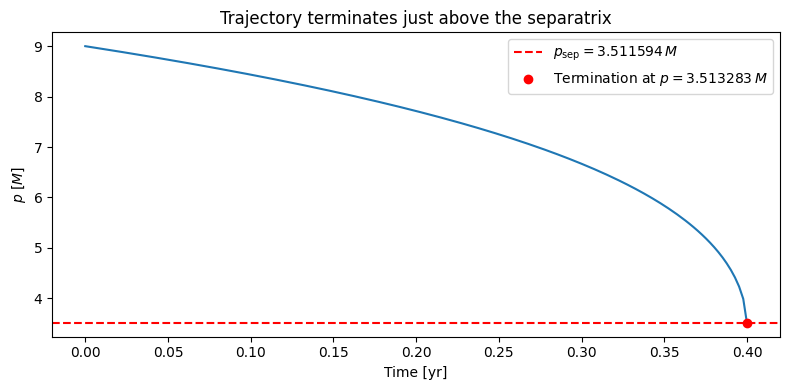

NameError: name 'DELTAP_SEP' is not defined

In [19]:
from fewtrax.utils.geodesic import get_separatrix

a = 0.7
t_, p_, e_, *_ = run_inspiral(
    a=a, p0=9.0, e0=0.3, T=5.0,  # 5 years, will plunge before then
    flux_data=flux_data, M=1e6, mu=50.0, dense_steps=2000,
)
valid_ = ~np.isinf(np.asarray(p_))
p_fin  = float(p_[valid_][-1])
e_fin  = float(e_[valid_][-1])
p_sep  = float(get_separatrix(a, e_fin, 1.0))

t_yr_ = np.asarray(t_)[valid_] / (365.25 * 24 * 3600)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_yr_, np.asarray(p_)[valid_])
ax.axhline(p_sep, color="r", linestyle="--", label=f"$p_{{\\rm sep}} = {p_sep:.6f}\\,M$")
ax.scatter([t_yr_[-1]], [p_fin], color="r", zorder=5, label=f"Termination at $p={p_fin:.6f}\\,M$")
ax.set_xlabel("Time [yr]")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("Trajectory terminates just above the separatrix")
ax.legend()
plt.tight_layout()
plt.show()

print(f'delta p = {np.abs(p_sep -p_fin)} < {DELTAP_SEP}')

## 2.5  JIT Timing

The ODE solve is wrapped in `@eqx.filter_jit`.  The first call traces and compiles; subsequent calls reuse the compiled kernel.

In [20]:
import time

traj = EMRIInspiral(flux_data)

call_kwargs = dict(p0=12.0, e0=0.4, a=0.7, T=1.0, M=1e6, mu=10.0, dense_steps=100)

# First call: compilation
t0 = time.perf_counter()
_ = traj(**call_kwargs)
t1 = time.perf_counter()
print(f"First call  (compile): {1000*(t1-t0):.0f} ms")

# Second and third calls: cached
for i in range(3):
    t0 = time.perf_counter()
    _ = traj(**call_kwargs)
    t1 = time.perf_counter()
    print(f"Call {i+2} (cached):     {1000*(t1-t0):.1f} ms")

First call  (compile): 11 ms
Call 2 (cached):     7.4 ms
Call 3 (cached):     8.3 ms
Call 4 (cached):     4.1 ms


## 2.6  vmap Over Initial Conditions

One of JAX's main advantages: `jax.vmap` vectorises a function over a batch of inputs with no Python loop overhead.  Here we compute trajectories for a grid of $(p_0, e_0)$ values simultaneously.

In [21]:
traj = EMRIInspiral(flux_data)

# Batch of N_start starting points
N_start = 1000
p0_batch = jnp.linspace(6.0, 10.0, N_start, dtype=jnp.float64)
e0_batch = jnp.full(N_start, 0.3, dtype=jnp.float64)

def single_traj(p0, e0):
    _, p, *_ = traj(p0=p0, e0=e0, a=0.99, T=2.0, M=1e6, mu=10.0, dense_steps=200)
    return p

# vmap over the first two arguments
batch_traj = jax.vmap(single_traj)

t0 = time.perf_counter()
p_batch = batch_traj(p0_batch, e0_batch)
t1 = time.perf_counter()
print(f"Batch of {len(p0_batch)} trajectories in {1000*(t1-t0):.1f} ms")
print(f"Output shape: {p_batch.shape}  (N_batch × N_steps)")

Batch of 1000 trajectories in 1386.6 ms
Output shape: (1000, 201)  (N_batch × N_steps)


In [22]:
batch_traj = jax.vmap(single_traj)

In [23]:
%%timeit
p_batch = batch_traj(p0_batch, e0_batch)

408 ms ± 9.39 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


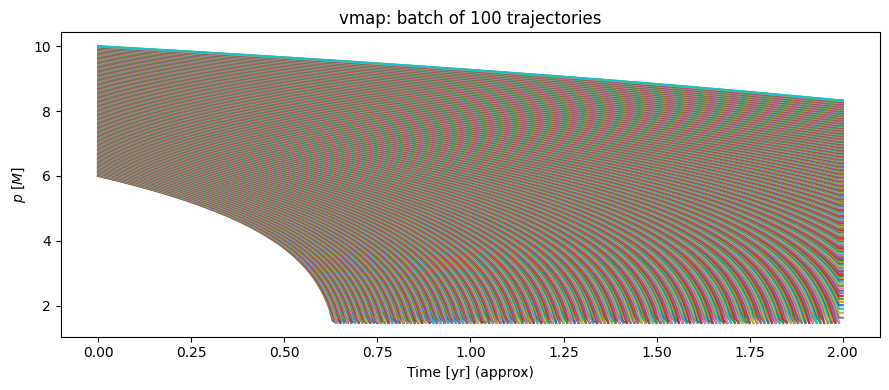

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
t_dummy = np.linspace(0, 2.0, 201)  # approximate time axis
for i in range(len(p0_batch)):
    p_i = np.asarray(p_batch[i])
    valid_ = ~np.isnan(p_i)
    ax.plot(t_dummy[valid_], p_i[valid_], label=f"$p_0={float(p0_batch[i]):.1f}$")
ax.set_xlabel("Time [yr] (approx)")
ax.set_ylabel("$p$ [$M$]")
ax.set_title("vmap: batch of 100 trajectories")
# ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Summary

The `EMRIInspiral` module:

1. Evaluates the PN-normalised fluxes from the FEW tables via JAX cubic splines
2. Converts $(\dot{E}, \dot{L})$ → $(\dot{p}, \dot{e})$ via `jax.jacfwd`, computed Jacobian inversion
3. Integrates the 5-component ODE $(p, e, \Phi_\phi, \Phi_\theta, \Phi_r)$ with `diffrax.Dopr87`
4. Stops at the separatrix via `diffrax.Event`
5. Scales $\dot{p}, \dot{e}$ by $\mu/M$ via the diffrax `args` mechanism

**Next:** [03_amplitude_interpolation.ipynb](03_amplitude_interpolation.ipynb) — evaluating Teukolsky mode amplitudes along the trajectory.

### Test the higher-order DOPR7 interpolant for better matches to FEW
As Federico pointed out, FEW uses a higher order interpolant for the phases. We should try to implement this as well before doing a side by side comparison. 